# FAILSAFE — Student Failure Risk Prediction
**ML Pipeline:** Data → EDA → Feature Engineering → **Three XGBoost Models** (pre / mid / full semester) → Isotonic Calibration → SHAP → Interventions

We train one model per *point in the semester* so faculty can run risk predictions before any grades are available, after G1, and after both G1 + G2. Categorical features are handled natively by XGBoost (`enable_categorical=True`, pandas `category` dtype). Probabilities are isotonically calibrated so the risk % shown to the user is meaningful.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings, joblib
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    brier_score_loss,
)

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
print('Libraries loaded.')

/Users/rachitgupta/Desktop/failsafe/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries loaded.


## 1. Load & Merge Data
The UCI Student Performance dataset comes in two separate files — one for Math and one for Portuguese. We load both, tag each row with its subject, and concatenate them into a single dataframe. This gives us ~1,044 student records with 33 features covering demographics, family background, study habits, and mid-term grades.

In [2]:
mat = pd.read_csv('student-mat.csv', sep=';')
por = pd.read_csv('student-por.csv', sep=';')
mat['subject'] = 'math'
por['subject'] = 'portuguese'
df = pd.concat([mat, por], ignore_index=True)
print(f'Math: {len(mat)} | Portuguese: {len(por)} | Total: {len(df)}')
df.head(3)

Math: 395 | Portuguese: 649 | Total: 1044


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,subject
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,math
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,math
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,math


## 2. Target Variable
We define our prediction target: a student is **at-risk** if their final grade `G3 < 10` (the passing threshold on the 0–20 scale). This converts the regression problem into a binary classification task. We also visualise the class balance here — if the dataset is heavily imbalanced, we'll need to account for that in training.

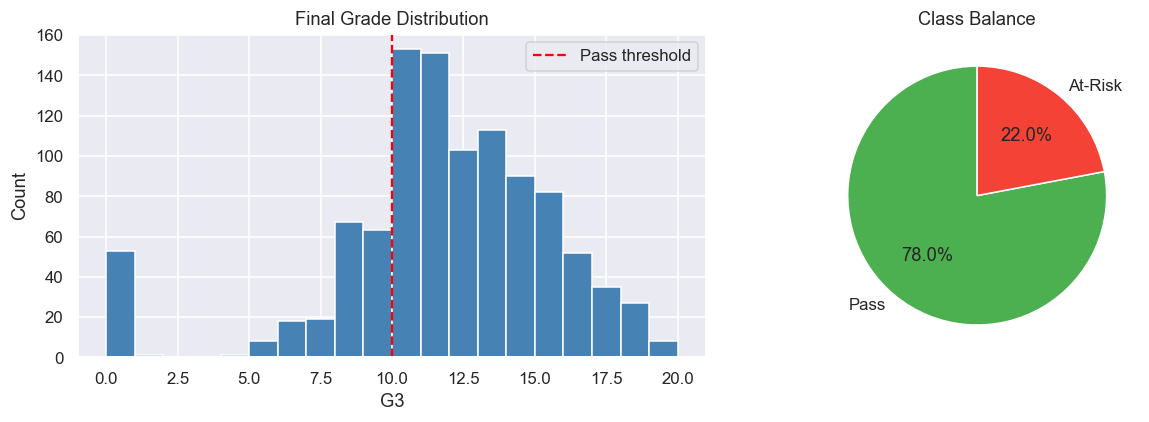

At-risk: 230 | Pass: 814


In [3]:
df['at_risk'] = (df['G3'] < 10).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['G3'].hist(bins=20, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(10, color='red', linestyle='--', label='Pass threshold')
axes[0].set(title='Final Grade Distribution', xlabel='G3', ylabel='Count')
axes[0].legend()

counts = df['at_risk'].value_counts()
axes[1].pie(counts, labels=['Pass', 'At-Risk'], autopct='%1.1f%%',
            colors=['#4CAF50', '#F44336'], startangle=90)
axes[1].set_title('Class Balance')
plt.tight_layout(); plt.show()
print(f'At-risk: {counts[1]} | Pass: {counts[0]}')

## 3. Feature Engineering
Instead of label-encoding categoricals into arbitrary integers (which tricks tree models into treating them as ordered), we cast every text column to pandas `category` dtype. XGBoost then handles them natively when we pass `enable_categorical=True`.

We also engineer six **always-available** signals — features that don't depend on G1/G2 and so can be used by every model in the pipeline:
- `alcohol_total` = Dalc + Walc
- `parent_edu` = Medu + Fedu
- `high_absences` = (absences > 10)
- `has_failures` = (failures > 0)
- `social_load` = goout + freetime — a proxy for time spent on non-academic activities
- `support_count` = how many of {school-support, family-support, paid-classes} the student has

These behavioural/background features carry more of the load in the start-of-semester model where no grades are available yet.

**Note:** `G3` (final grade) is dropped to prevent target leakage — we only use G1 and G2 as early-semester signals, and the per-stage feature frames are built later.

In [4]:
df = df.drop(columns=['G3'])  # drop target-leaking final grade

# Always-available engineered signals (independent of G1/G2)
df['alcohol_total'] = df['Dalc'] + df['Walc']
df['parent_edu']    = df['Medu'] + df['Fedu']
df['high_absences'] = (df['absences'] > 10).astype(int)
df['has_failures']  = (df['failures'] > 0).astype(int)
df['social_load']   = df['goout'] + df['freetime']
df['support_count'] = (
    (df['schoolsup'] == 'yes').astype(int)
    + (df['famsup']  == 'yes').astype(int)
    + (df['paid']    == 'yes').astype(int)
)

CATEGORICAL_COLS = [
    'school','sex','address','famsize','Pstatus',
    'Mjob','Fjob','reason','guardian',
    'schoolsup','famsup','paid','activities','nursery',
    'higher','internet','romantic','subject',
]
for c in CATEGORICAL_COLS:
    df[c] = df[c].astype('category')

print(f'Total columns: {df.shape[1]-1} features + 1 target')
print(f'Categorical: {len(CATEGORICAL_COLS)}, Numeric: {df.shape[1]-1-len(CATEGORICAL_COLS)}')
df.dtypes.value_counts()

Total columns: 39 features + 1 target
Categorical: 18, Numeric: 21


int64       22
category     8
category     2
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
Name: count, dtype: int64

## 4. Exploratory Analysis
Before modelling, we visually inspect how key features differ between at-risk and passing students. KDE plots show the probability density for each group, making it easy to spot where distributions diverge. The correlation bar chart then shows which features have the strongest linear relationship with the at-risk label — positive bars increase risk, negative bars reduce it. This step guides feature selection intuition and sanity-checks the engineering above.

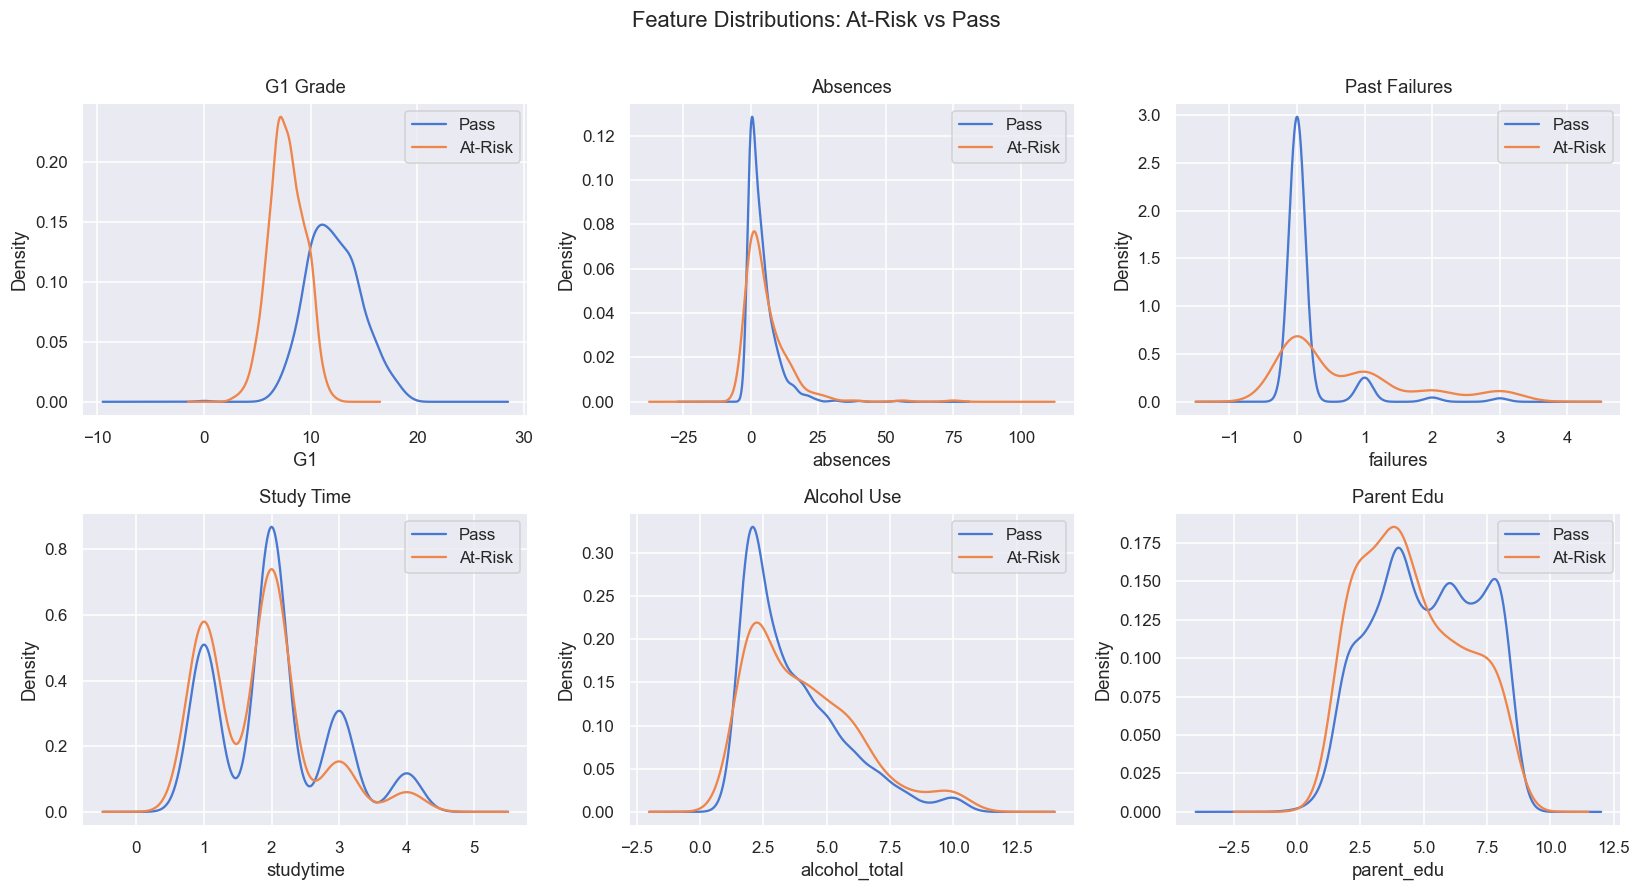

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
features = ['G1', 'absences', 'failures', 'studytime', 'alcohol_total', 'parent_edu']
labels   = ['G1 Grade', 'Absences', 'Past Failures', 'Study Time', 'Alcohol Use', 'Parent Edu']

for ax, feat, lbl in zip(axes.flat, features, labels):
    df.groupby('at_risk')[feat].plot.kde(ax=ax)
    ax.set(title=lbl, xlabel=feat)
    ax.legend(['Pass', 'At-Risk'])

plt.suptitle('Feature Distributions: At-Risk vs Pass', y=1.01)
plt.tight_layout(); plt.show()

From the above graphs, we can see, avg early grade is a strong indicator. Parents education and past failure also have some correlation with at risk students.


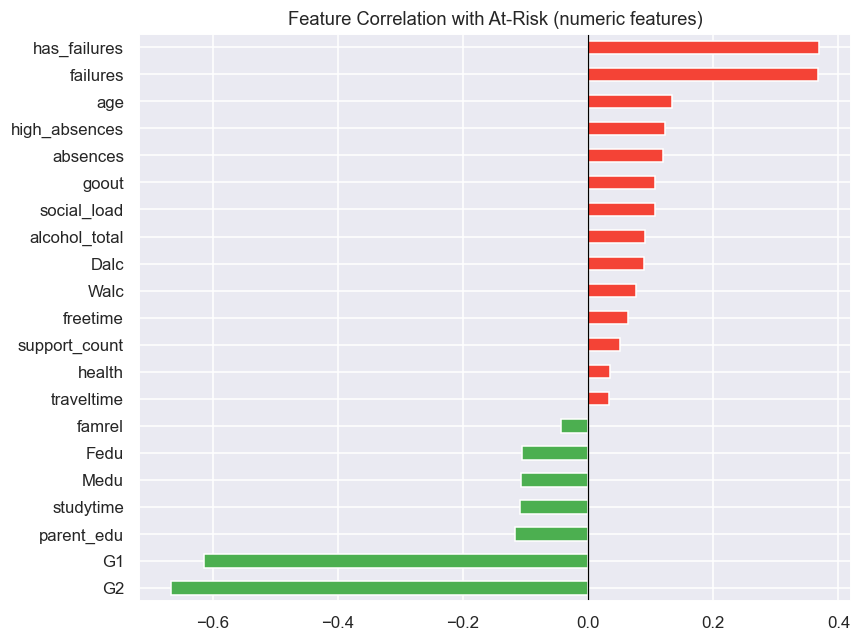

In [6]:
# Correlation over numeric columns only (categoricals can't be correlated meaningfully)
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()['at_risk'].drop('at_risk').sort_values()
plt.figure(figsize=(8, 6))
corr.plot(kind='barh', color=['#F44336' if v > 0 else '#4CAF50' for v in corr])
plt.axvline(0, color='black', lw=0.8)
plt.title('Feature Correlation with At-Risk (numeric features)')
plt.tight_layout(); plt.show()

From correlation graphs, we can see that past failures has huge correlations with at risk students and earlier grades has huge negative correlation.

## 5. Stage-Specific Feature Frames
We build three views of the data — one per point in the semester:

| Stage  | When used                  | Excludes      | Adds                              |
|--------|----------------------------|---------------|-----------------------------------|
| `pre`  | Start of semester          | G1, G2        | —                                 |
| `mid`  | After G1 reported          | G2            | —                                 |
| `full` | After both G1 + G2 reported | (nothing)     | `avg_early_grade`, `grade_trend`  |

A single stratified 80/20 split is used per stage; the test set is held out and only seen at evaluation.

In [7]:
def build_stage(df, stage):
    """stage ∈ {'pre','mid','full'}"""
    d = df.copy()
    if stage == 'pre':
        d = d.drop(columns=['G1', 'G2'])
    elif stage == 'mid':
        d = d.drop(columns=['G2'])
    elif stage == 'full':
        d['avg_early_grade'] = (d['G1'] + d['G2']) / 2.0
        d['grade_trend']     = d['G2'] - d['G1']
    else:
        raise ValueError(stage)
    return d

stage_dfs = {s: build_stage(df, s) for s in ('pre', 'mid', 'full')}

splits = {}
for stage, sdf in stage_dfs.items():
    X = sdf.drop(columns=['at_risk'])
    y = sdf['at_risk']
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    splits[stage] = (X_tr, X_te, y_tr, y_te)
    print(f'{stage:5s} → {X.shape[1]:2d} features  |  train={len(X_tr)}  test={len(X_te)}')

pre   → 37 features  |  train=835  test=209
mid   → 38 features  |  train=835  test=209
full  → 41 features  |  train=835  test=209


## 6. Train the Three Models (with calibration)
For each stage we train **two** XGBoost objects:

1. A **raw classifier** — used for SHAP explanations (TreeExplainer needs the underlying tree model).
2. A **`CalibratedClassifierCV` wrapper** with isotonic regression on 5 folds — used to serve probabilities to the user.

Why calibration? An imbalanced loss / un-calibrated XGBoost tends to push probabilities toward 0 / 1, so the "risk %" shown to a faculty member becomes meaningless ("everyone is 99% at risk"). Isotonic calibration on a held-out fold maps raw scores back to honest probabilities. We track the Brier score before vs after calibration as a sanity check.

The PRE model also uses slightly stronger regularisation (`max_depth=3`, `reg_lambda=2`) since with G1/G2 stripped out, the signal is weaker and the model is more prone to overfit on noise.

In [8]:
def xgb_params(stage):
    if stage == 'pre':
        return dict(n_estimators=400, max_depth=3, learning_rate=0.04,
                    subsample=0.8, colsample_bytree=0.8,
                    reg_lambda=2.0, min_child_weight=3)
    return dict(n_estimators=400, max_depth=4, learning_rate=0.05,
                subsample=0.85, colsample_bytree=0.85,
                reg_lambda=1.0, min_child_weight=2)

COMMON = dict(enable_categorical=True, tree_method='hist',
              eval_metric='logloss', random_state=42, n_jobs=-1)

models = {}
for stage, (X_tr, X_te, y_tr, y_te) in splits.items():
    params = xgb_params(stage)
    raw = XGBClassifier(**params, **COMMON).fit(X_tr, y_tr, verbose=False)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cal = CalibratedClassifierCV(
        estimator=XGBClassifier(**params, **COMMON),
        method='isotonic', cv=cv,
    ).fit(X_tr, y_tr)

    models[stage] = {'raw': raw, 'cal': cal}
    print(f'{stage:5s}: trained raw + calibrated')

print('\nAll three models trained.')

pre  : trained raw + calibrated


mid  : trained raw + calibrated


full : trained raw + calibrated

All three models trained.


## 7. Evaluation — Side by Side
We evaluate all three models on their respective held-out test sets. The expectation:
- **`full`** should be the strongest (G1 + G2 are huge signals).
- **`mid`** should be in the middle.
- **`pre`** should be the weakest, since with no grades the model has to lean on behaviour + background features only.

We report ROC-AUC, Average Precision, and Brier score (the lower the better — measures probability calibration quality).

In [9]:
metrics = {}
for stage, m in models.items():
    X_tr, X_te, y_tr, y_te = splits[stage]
    y_prob_raw = m['raw'].predict_proba(X_te)[:, 1]
    y_prob_cal = m['cal'].predict_proba(X_te)[:, 1]
    y_pred     = (y_prob_cal >= 0.5).astype(int)

    print(f'\n=== {stage.upper()} ===')
    print(classification_report(y_te, y_pred, target_names=['Pass', 'At-Risk']))
    metrics[stage] = {
        'ROC-AUC':   roc_auc_score(y_te, y_prob_cal),
        'AvgPrec':   average_precision_score(y_te, y_prob_cal),
        'Brier_raw': brier_score_loss(y_te, y_prob_raw),
        'Brier_cal': brier_score_loss(y_te, y_prob_cal),
    }

summary = pd.DataFrame(metrics).T.round(3)
print('\nSummary:')
summary


=== PRE ===
              precision    recall  f1-score   support

        Pass       0.84      0.94      0.89       163
     At-Risk       0.64      0.35      0.45        46

    accuracy                           0.81       209
   macro avg       0.74      0.65      0.67       209
weighted avg       0.79      0.81      0.79       209


=== MID ===
              precision    recall  f1-score   support

        Pass       0.92      0.89      0.90       163
     At-Risk       0.65      0.72      0.68        46

    accuracy                           0.85       209
   macro avg       0.78      0.80      0.79       209
weighted avg       0.86      0.85      0.85       209


=== FULL ===
              precision    recall  f1-score   support

        Pass       0.95      0.94      0.95       163
     At-Risk       0.81      0.83      0.82        46

    accuracy                           0.92       209
   macro avg       0.88      0.89      0.88       209
weighted avg       0.92      0.92 

,ROC-AUC,AvgPrec,Brier_raw,Brier_cal
pre,0.778,0.582,0.138,0.135
mid,0.925,0.766,0.102,0.090
full,0.973,0.921,0.065,0.058


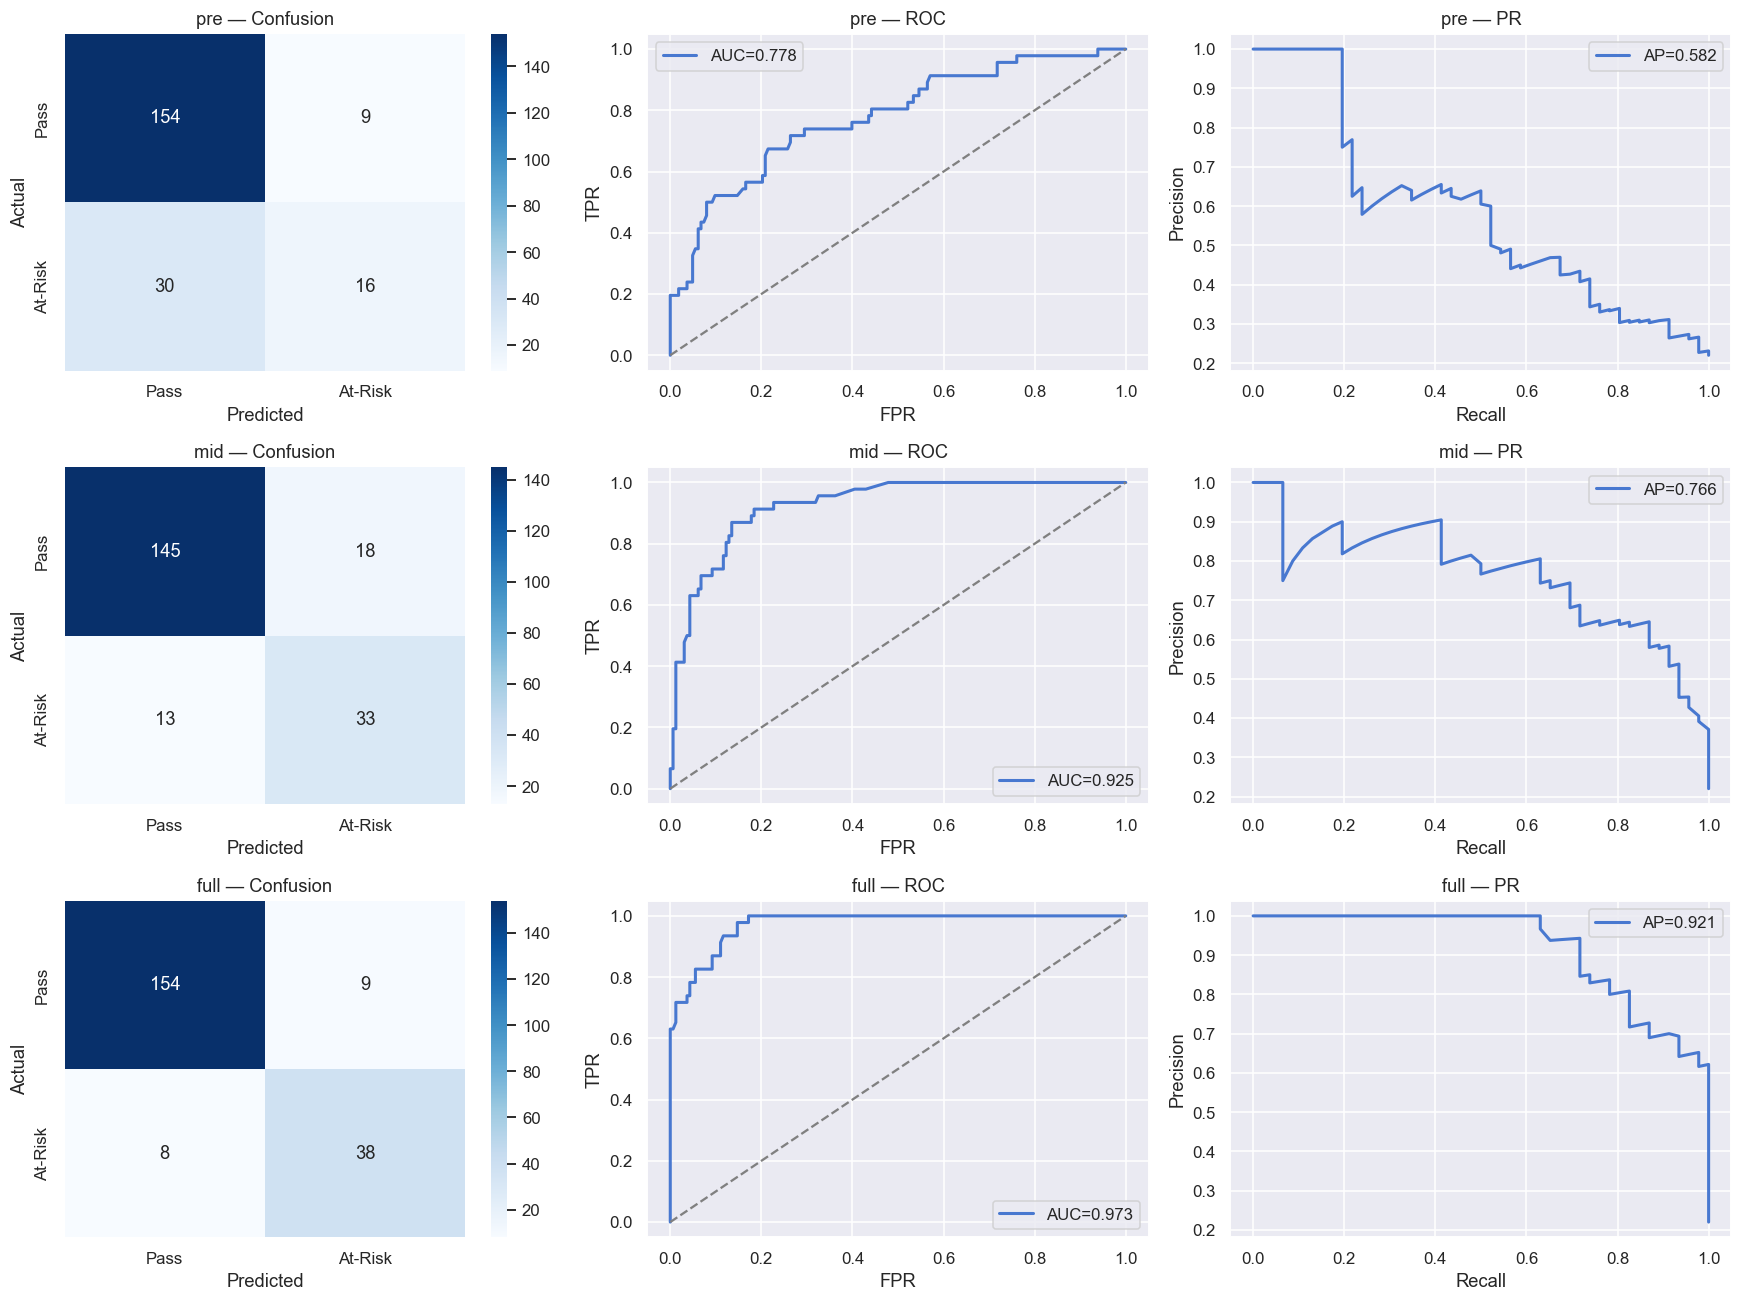

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for i, (stage, m) in enumerate(models.items()):
    X_tr, X_te, y_tr, y_te = splits[stage]
    y_prob = m['cal'].predict_proba(X_te)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    sns.heatmap(confusion_matrix(y_te, y_pred), annot=True, fmt='d',
                cmap='Blues', ax=axes[i, 0],
                xticklabels=['Pass','At-Risk'], yticklabels=['Pass','At-Risk'])
    axes[i, 0].set(title=f'{stage} — Confusion', xlabel='Predicted', ylabel='Actual')

    fpr, tpr, _ = roc_curve(y_te, y_prob)
    axes[i, 1].plot(fpr, tpr, lw=2, label=f'AUC={roc_auc_score(y_te, y_prob):.3f}')
    axes[i, 1].plot([0,1],[0,1], '--', color='grey')
    axes[i, 1].set(title=f'{stage} — ROC', xlabel='FPR', ylabel='TPR'); axes[i, 1].legend()

    prec, rec, _ = precision_recall_curve(y_te, y_prob)
    axes[i, 2].plot(rec, prec, lw=2, label=f'AP={average_precision_score(y_te, y_prob):.3f}')
    axes[i, 2].set(title=f'{stage} — PR', xlabel='Recall', ylabel='Precision'); axes[i, 2].legend()

plt.tight_layout(); plt.show()

## 7b. Error-Rate Breakdown — False Positives vs False Negatives

A confusion matrix tells us *where* each model fails. For an intervention
system the two error types have very different costs:

- **False Negative (FN)** — student is actually at risk, model says *Pass*.
  We miss the chance to intervene. **This is the expensive error.**
- **False Positive (FP)** — student would pass on their own, model says *At-Risk*.
  We spend support resources on someone who didn't need them.

The plots below show the count matrices and the derived rates per stage:

- **FPR** = FP / (FP + TN)  — fraction of passing students wrongly flagged.
- **FNR** = FN / (FN + TP)  — fraction of at-risk students we missed.
- **Recall (sensitivity)** = 1 − FNR — fraction of at-risk students we *caught*.
- **Precision** = TP / (TP + FP) — when we flag a student, how often we're right.


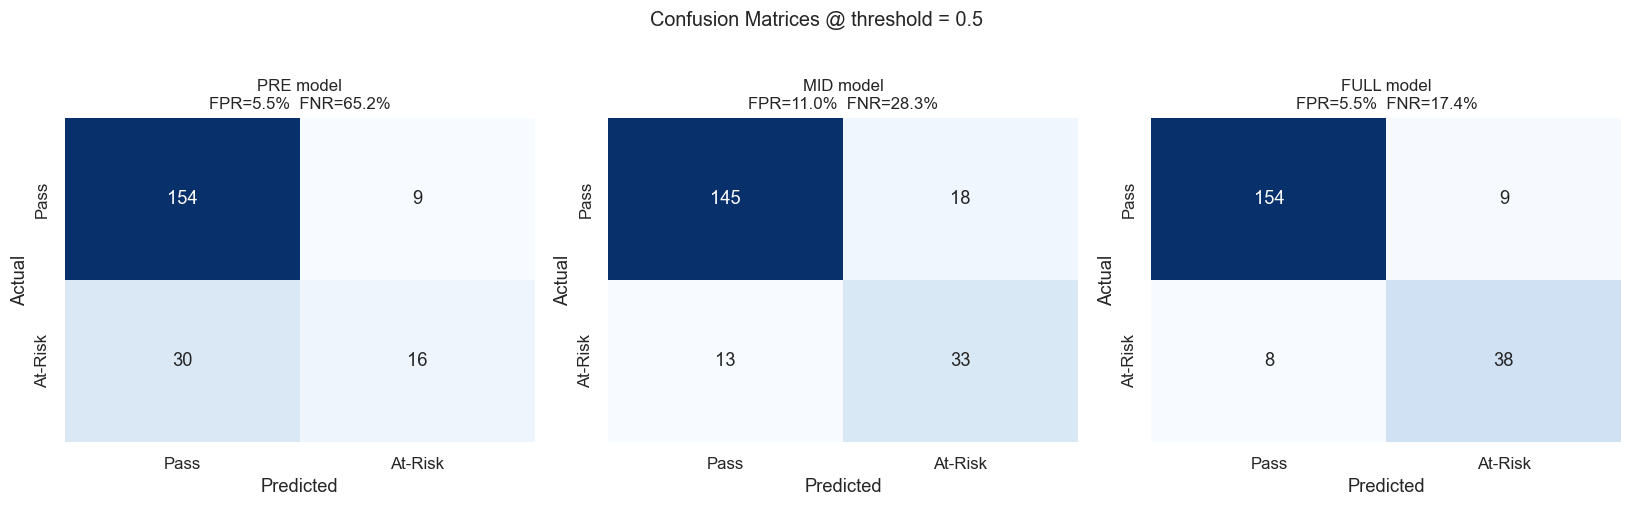


Per-stage error rates:


,TN,FP,FN,TP,FPR,FNR,Precision,Recall
stage,,,,,,,,
pre,154,9,30,16,0.055,0.652,0.640,0.348
mid,145,18,13,33,0.110,0.283,0.647,0.717
full,154,9,8,38,0.055,0.174,0.809,0.826


In [11]:
cm_rows = []
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (stage, m) in zip(axes, models.items()):
    _, X_te, _, y_te = splits[stage]
    y_prob = m['cal'].predict_proba(X_te)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    cm = confusion_matrix(y_te, y_pred)
    tn, fp, fn, tp = cm.ravel()
    fpr  = fp / (fp + tn) if (fp + tn) else 0.0
    fnr  = fn / (fn + tp) if (fn + tp) else 0.0
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec  = tp / (tp + fn) if (tp + fn) else 0.0

    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['Pass', 'At-Risk'], yticklabels=['Pass', 'At-Risk'],
        cbar=False,
    )
    ax.set_title(
        f"{stage.upper()} model\n"
        f"FPR={fpr:.1%}  FNR={fnr:.1%}",
        fontsize=11,
    )
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

    cm_rows.append({
        'stage': stage,
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
        'FPR': round(fpr, 3),
        'FNR': round(fnr, 3),
        'Precision': round(prec, 3),
        'Recall':    round(rec, 3),
    })

plt.suptitle('Confusion Matrices @ threshold = 0.5', y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

cm_df = pd.DataFrame(cm_rows).set_index('stage')
print("\nPer-stage error rates:")
cm_df


## 8. SHAP — Explainable AI
We focus the explanation plots on the **FULL** model since it's the highest-accuracy view, but the same `TreeExplainer` machinery works for the `pre` and `mid` models too (the backend builds an explainer per stage).

- **Bar plot**: global average feature importance — which features matter most across all students
- **Beeswarm plot**: shows both the magnitude *and direction* of each feature's impact

This makes the model's reasoning transparent and auditable for non-technical faculty.

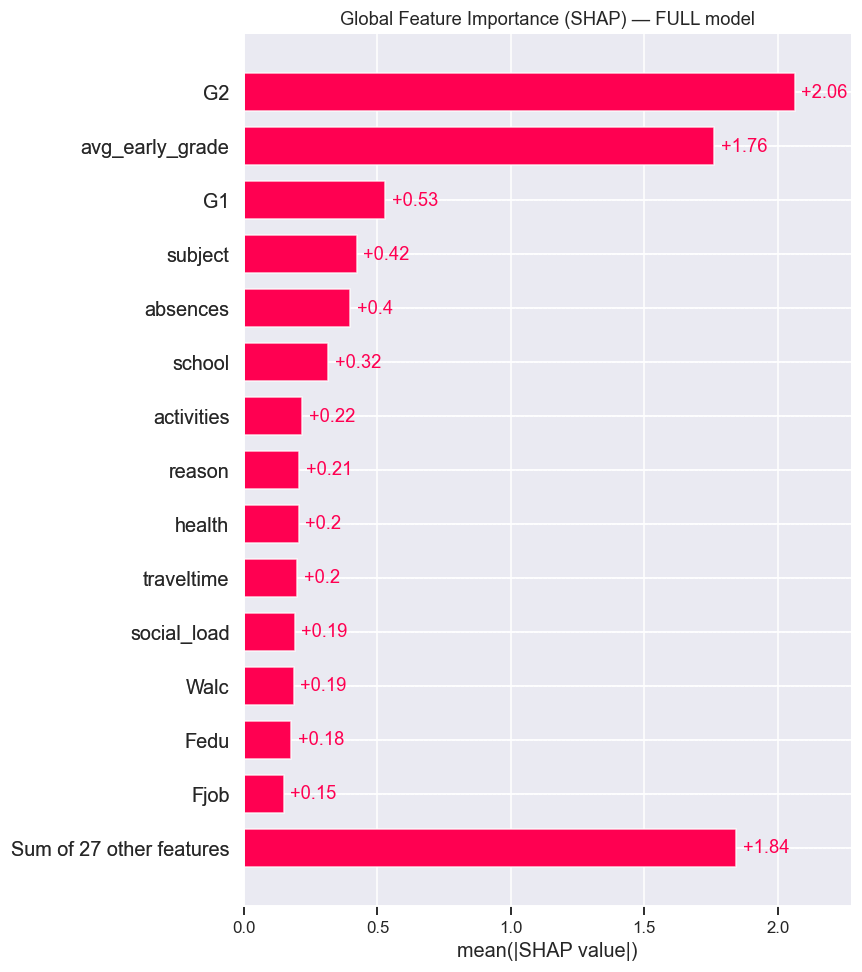

In [12]:
full_raw = models['full']['raw']
_, X_te_full, _, _ = splits['full']

explainer   = shap.TreeExplainer(full_raw)
shap_values = explainer(X_te_full)

plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title('Global Feature Importance (SHAP) — FULL model')
plt.tight_layout(); plt.show()

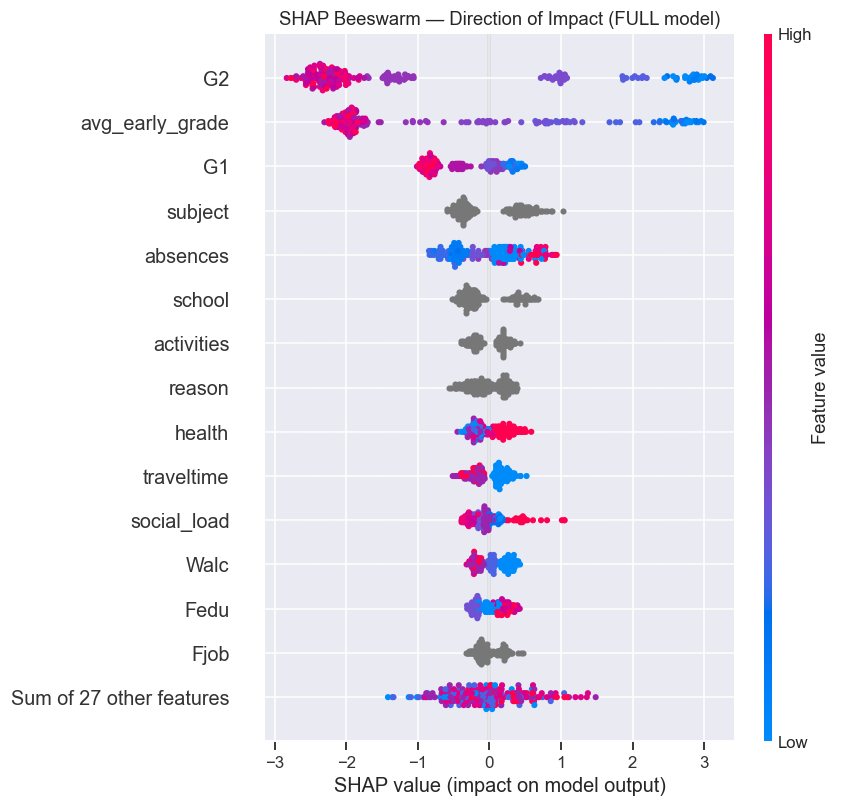

In [13]:
plt.figure(figsize=(10, 7))
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title('SHAP Beeswarm — Direction of Impact (FULL model)')
plt.tight_layout(); plt.show()

## 9. Per-Student Report & Intervention Plan
For each flagged student, we generate a personalised two-part report:
1. **SHAP drivers**: the top 5 features pushing the student's risk score up or down, with their actual values
2. **Intervention plan**: rule-based recommendations triggered by the student's specific risk factors (e.g. high absences → attendance monitoring, low grades → tutoring, past failures → peer mentor)

We also plot a **SHAP waterfall chart** for the highest-risk student — a visual explanation of exactly *why* the model flagged them, starting from the base rate and showing each feature's additive contribution.

In [14]:
INTERVENTIONS = [
    ('avg_early_grade', lambda v: v < 10,        'Enrol in extra tutoring; weekly grade check-ins with faculty.'),
    ('grade_trend',     lambda v: v < 0,         'Grade declining — urgent counselling to identify blockers.'),
    ('G1',              lambda v: v < 10,        'Low G1 grade — schedule mid-semester tutoring.'),
    ('absences',        lambda v: v > 10,        'High absenteeism — attendance monitoring + guardian contact.'),
    ('failures',        lambda v: v > 0,         'Past failures — assign peer mentor + remedial materials.'),
    ('studytime',       lambda v: v < 2,         'Low study time — structured plan recommended (2-4 hrs/day).'),
    ('alcohol_total',   lambda v: v > 4,         'High alcohol use — refer to student wellness services.'),
    ('internet',        lambda v: str(v) == 'no','No internet — provide library access + offline resources.'),
]

def student_report(student_row, shap_row, risk_prob):
    level = 'HIGH' if risk_prob >= 0.6 else ('MEDIUM' if risk_prob >= 0.4 else 'LOW')
    shap_s = pd.Series(shap_row.values, index=shap_row.feature_names)
    top5   = shap_s.abs().nlargest(5).index

    lines = ['=== STUDENT RISK REPORT ===',
             f'Risk: {risk_prob:.1%}  [{level}]', '',
             'TOP SHAP DRIVERS:']
    for f in top5:
        v = student_row[f]
        d = '+risk' if shap_s[f] > 0 else '-risk'
        lines.append(f'  {f}: {v}  (SHAP {shap_s[f]:+.3f}, {d})')

    lines += ['', 'INTERVENTIONS:']
    plans = []
    for feat, check, msg in INTERVENTIONS:
        if feat in student_row.index:
            v = student_row[feat]
            if pd.isna(v):
                continue
            try:
                if check(v):
                    plans.append(f'  • {msg}')
            except Exception:
                pass
    lines += plans or ['  • No immediate intervention required.']
    return '\n'.join(lines)

# Show report for highest-risk student in the FULL test set
y_prob_full = models['full']['cal'].predict_proba(X_te_full)[:, 1]
idx = int(np.argmax(y_prob_full))
print(student_report(X_te_full.iloc[idx], shap_values[idx], y_prob_full[idx]))

=== STUDENT RISK REPORT ===
Risk: 100.0%  [HIGH]

TOP SHAP DRIVERS:
  G2: 0  (SHAP +2.822, +risk)
  avg_early_grade: 2.5  (SHAP +2.537, +risk)
  subject: math  (SHAP +0.412, +risk)
  G1: 5  (SHAP +0.326, +risk)
  social_load: 9  (SHAP +0.237, +risk)

INTERVENTIONS:
  • Enrol in extra tutoring; weekly grade check-ins with faculty.
  • Grade declining — urgent counselling to identify blockers.
  • Low G1 grade — schedule mid-semester tutoring.
  • Past failures — assign peer mentor + remedial materials.
  • Low study time — structured plan recommended (2-4 hrs/day).


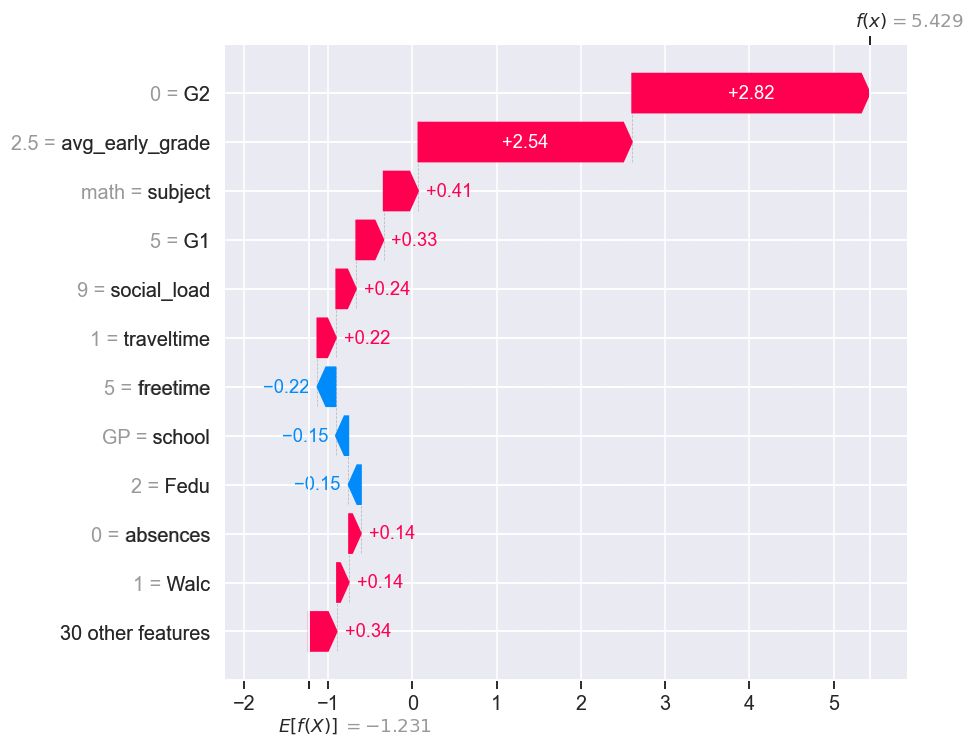

In [15]:
# Waterfall — why THIS student was flagged
shap.plots.waterfall(shap_values[idx], max_display=12)

## 10. Risk Dashboard — All Students (FULL model)
We compile every test-set student into a ranked dashboard sorted by **calibrated** risk probability. Students are bucketed into three tiers:
- **Low** (< 40%): routine monitoring
- **Medium** (40–60%): watch closely, consider light intervention
- **High** (> 60%): immediate intervention required

This view is what a faculty member or HOD would see at the start of each week to prioritise their attention.

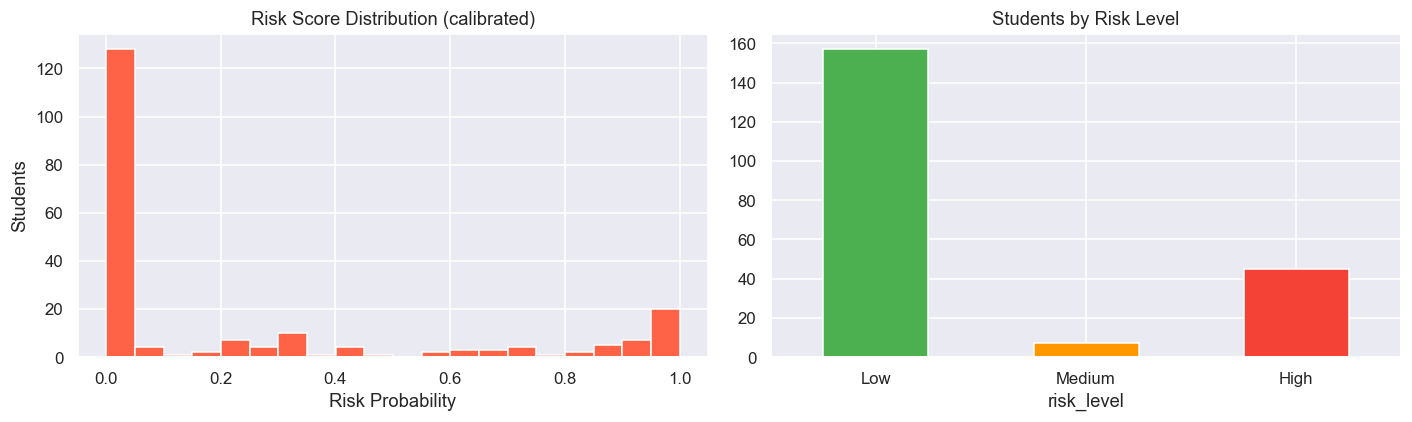

Top 10 Highest-Risk Students:


,avg_early_grade,absences,failures,risk_prob,risk_level,actual
982,6.5,3,1,1.000000,High,1
153,2.5,0,3,1.000000,High,1
18,5.5,16,3,1.000000,High,1
962,2.0,0,1,1.000000,High,1
100,7.0,14,0,1.000000,High,1
160,6.5,0,2,1.000000,High,1
134,4.5,0,0,1.000000,High,1
389,5.5,0,1,0.988921,High,1
332,3.5,0,0,0.985387,High,1
35,7.5,0,0,0.984615,High,1


In [16]:
_, X_te_full, _, y_te_full = splits['full']
results = X_te_full.copy()
results['risk_prob']  = y_prob_full
results['actual']     = y_te_full.values
results['risk_level'] = pd.cut(results['risk_prob'],
                                bins=[-0.001, 0.4, 0.6, 1.0],
                                labels=['Low', 'Medium', 'High'])
dashboard = results.sort_values('risk_prob', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
dashboard['risk_prob'].hist(bins=20, ax=axes[0], color='tomato', edgecolor='white')
axes[0].set(title='Risk Score Distribution (calibrated)', xlabel='Risk Probability', ylabel='Students')

dashboard['risk_level'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color=['#4CAF50','#FF9800','#F44336'], edgecolor='white')
axes[1].set(title='Students by Risk Level'); axes[1].tick_params(rotation=0)
plt.tight_layout(); plt.show()

print('Top 10 Highest-Risk Students:')
dashboard[['avg_early_grade','absences','failures','risk_prob','risk_level','actual']].head(10)

## 11. Save Bundle — All Three Models
We serialise all three model bundles into one file (`models_bundle.pkl`) so the backend can load them in a single I/O call. Each bundle contains:
- `model` — the raw XGBoost classifier (for SHAP)
- `calibrator` — the `CalibratedClassifierCV` wrapper (for serving probabilities)
- `features` — ordered list of feature names this model was trained on
- `categorical` — the category set for each categorical column, so unseen inputs can be aligned at inference
- `metrics` — the held-out evaluation metrics we just computed

In [17]:
bundle = {}
for stage, m in models.items():
    X_tr, _, _, _ = splits[stage]
    categories = {c: list(X_tr[c].cat.categories)
                  for c in CATEGORICAL_COLS if c in X_tr.columns}
    bundle[stage] = {
        'model':       m['raw'],
        'calibrator':  m['cal'],
        'features':    X_tr.columns.tolist(),
        'categorical': categories,
        'metrics':     {k: float(v) for k, v in metrics[stage].items()},
    }

joblib.dump(bundle, 'models_bundle.pkl')
print('Saved → models_bundle.pkl  (contains: pre, mid, full)')

Saved → models_bundle.pkl  (contains: pre, mid, full)


## 12. Inference — Predict at Any Stage
A single helper that picks the right model based on which grades the caller supplies. This mirrors what the FastAPI backend does in `backend/predict.py` — given a raw student dict, it auto-detects available stages and returns one calibrated risk score per stage.

In [18]:
def _prep_row(raw, stage_bundle):
    d = dict(raw)
    d['alcohol_total'] = float(d.get('Dalc', 0)) + float(d.get('Walc', 0))
    d['parent_edu']    = float(d.get('Medu', 0)) + float(d.get('Fedu', 0))
    d['high_absences'] = int(float(d.get('absences', 0)) > 10)
    d['has_failures']  = int(float(d.get('failures', 0)) > 0)
    d['social_load']   = float(d.get('goout', 0)) + float(d.get('freetime', 0))
    d['support_count'] = sum(int(str(d.get(k, 'no')) == 'yes')
                             for k in ('schoolsup','famsup','paid'))
    if 'avg_early_grade' in stage_bundle['features']:
        g1, g2 = d.get('G1'), d.get('G2')
        if g1 is not None and g2 is not None:
            d['avg_early_grade'] = (float(g1) + float(g2)) / 2.0
            d['grade_trend']     = float(g2) - float(g1)
    row = pd.DataFrame([{f: d.get(f, None) for f in stage_bundle['features']}])
    for col, cats in stage_bundle['categorical'].items():
        if col in row.columns:
            row[col] = pd.Categorical(row[col], categories=cats)
    for col in row.columns:
        if col not in stage_bundle['categorical']:
            row[col] = pd.to_numeric(row[col], errors='coerce')
    return row

def predict_any_stage(raw):
    """Auto-detect which stages can run on the given raw student dict."""
    b = joblib.load('models_bundle.pkl')
    stages = ['pre']
    if raw.get('G1') is not None: stages.append('mid')
    if raw.get('G1') is not None and raw.get('G2') is not None: stages.append('full')

    out = []
    for s in stages:
        sb = b[s]
        row  = _prep_row(raw, sb)
        prob = float(sb['calibrator'].predict_proba(row)[0, 1])
        level = 'HIGH' if prob >= 0.6 else ('MEDIUM' if prob >= 0.4 else 'LOW')
        out.append({'stage': s, 'risk_prob': prob, 'risk_level': level})
    return out

# Smoke test: a typical mid-grade student
sample = X_te_full.iloc[0].to_dict()
for r in predict_any_stage(sample):
    print(f"{r['stage']:5s}  risk={r['risk_prob']:.1%}  [{r['risk_level']}]")

pre    risk=20.1%  [LOW]
mid    risk=69.5%  [HIGH]
full   risk=96.6%  [HIGH]
